In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import meshplot
from tqdm.notebook import tqdm
import igl

from IPython.display import IFrame

In [2]:
import jax.numpy as jnp
import jax

In [3]:
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)

In [4]:
from jaxtyping import Float

In [5]:
from triangulax.mesh import HeMesh
from triangulax import geometry as geom
from triangulax import adjacency as adj
from triangulax import linops as linops
from triangulax import algorithms as alg
from triangulax import elastic
from triangulax.triangular import read_obj, write_obj

# Convergence of geometry discretizations under mesh refinement

The goal of this notebook is to check the convergence of the discretized differential-geometry operators on a series of test meshes, where an analytical answer is available.

**Quantities to test**

- Mean and Gaussian curvatures `geom.get_mean_curvature_laplace`, `geom.get_gaussian_curvature`
- Gradient and Laplace operators `linops.compute_gradient_3d`, `linops.compute_cotan_laplace`
- Metric tensor and 2nd fundamental form `elastic.get_metric`, `elastic.get_second_fundamental_form`

We'll also test the mean curvature defined by barycentric areas + dihedral angles, which should perform worse.

**Meshes to test on**

- Flat plane
- Saddle-point surface (created by deforming the flat plane mesh using a height function)
- Torus
- Sphere
- Surface of revolution (e.g. ellipsoid, created by deforming the sphere mesh)

All meshes can be loaded in 4 resolutions on a logarithmic scale. For these parameteric surfaces, analytical solutions exist (see wikipedia: https://en.wikipedia.org/wiki/Differential_geometry_of_surfaces, https://en.wikipedia.org/wiki/Ellipsoid, https://en.wikipedia.org/wiki/Torus, )




In [6]:
def get_mean_curvature_barycentric(vertices: Float[jax.Array, "V D"], hemesh: HeMesh) -> Float[jax.Array, "V"]:
    """Compute mean curvature at vertices using barycentric area normalization."""
    H = geom.get_mean_curvature_dihedral(vertices, hemesh, normalize=False)
    A = geom.get_barycentric_cell_areas(vertices, hemesh)
    return H / A

### Loading the test meshes

In [14]:
MESH_DIR = "tutorial_meshes/refinement_tests"
AVAILABLE_RESOLUTIONS = [0.25, 0.5, 1, 2, 4] # available resolutions (edge lengths as % of bounding box diagonal)

In [15]:
def load_sphere(resolution, radius=1):
    """Loads, centers, and scales a sphere mesh from the MESH_DIR directory."""
    vertices, faces = read_obj(f"{MESH_DIR}/sphere_{resolution}.obj", dim=3)
    vertices = vertices - vertices.mean(axis=0)
    vertices = radius * jnp.asarray((vertices.T / np.linalg.norm(vertices, axis=1)).T)
    return vertices, HeMesh.from_triangles(vertices.shape[0], faces)

def load_plane(resolution):
    """Loads 2D plane mesh from the MESH_DIR directory. Centered and aligned with z=0 plane."""
    vertices, faces = read_obj(f"{MESH_DIR}/plane_{resolution}.obj", dim=3)
    vertices = jnp.roll(vertices, shift=1, axis=1)
    vertices = vertices - vertices.mean(axis=0)
    return vertices, HeMesh.from_triangles(vertices.shape[0], faces)

def load_torus(resolution, major_radius=1, minor_radius=0.25):
    """Loads torus mesh from the MESH_DIR directory.
    Centered, aligned with z=0 plane. Default major radius=1, minor radius=0.25."""
    vertices, faces = read_obj(f"{MESH_DIR}/torus_{resolution}.obj", dim=3)
    vertices = jnp.roll(vertices, shift=1, axis=1)
    # project to torus surface with desired major and minor radius
    theta = jnp.arctan2(vertices[:,1], vertices[:,0])
    centerline_points = major_radius * jnp.stack([jnp.cos(theta), jnp.sin(theta), jnp.zeros_like(theta)], axis=1)
    direction_vectors = vertices - centerline_points
    direction_vectors = direction_vectors / jnp.linalg.norm(direction_vectors, axis=1, keepdims=True)
    vertices = centerline_points + minor_radius * direction_vectors
    # center the torus
    vertices = vertices - vertices.mean(axis=0)
    return vertices, HeMesh.from_triangles(vertices.shape[0], faces)


In [16]:
def load_saddle(resolution, amplitude=0.5):
    """Deform the plane into a hyperbolic-paraboloid saddle z = A (x^2 - y^2).
    Gaussian curvature K < 0 everywhere; mean curvature H changes sign across |x| = |y|."""
    vertices, hemesh = load_plane(resolution)
    z = amplitude * (vertices[:, 0]**2 - vertices[:, 1]**2)
    return vertices.at[:, 2].set(z), hemesh

def load_ellipsoid(resolution, axes=(1.0, 0.8, 0.6)):
    """Scale the sphere anisotropically into an ellipsoid x^2/a^2 + y^2/b^2 + z^2/c^2 = 1.
    The anisotropic scaling destroys the local symmetry of the (isotropic) sphere remesh."""
    vertices, hemesh = load_sphere(resolution)
    return vertices * jnp.array(axes), hemesh

LOADERS = {"plane": load_plane, "saddle": load_saddle, "sphere": load_sphere,
           "ellipsoid": load_ellipsoid, "torus": load_torus}
CLOSED_SURFACES = {"sphere", "ellipsoid", "torus"}   # closed = no boundary vertices
COLORS = {"sphere": "tab:blue", "ellipsoid": "tab:orange", "torus": "tab:green",
          "saddle": "tab:red", "plane": "tab:gray"}

In [17]:
v_sphere, hemesh_sphere = load_sphere(1)
v_plane, hemesh_plane = load_plane(1)
v_torus, hemesh_torus = load_torus(1)

  o Sphere_iso_remesh_1
  o Plane_iso_remesh_1
  o Torus_iso_remesh_1


(np.float64(-1.3752000440034),
 np.float64(1.3747445712180635),
 np.float64(-1.3746679075043755),
 np.float64(1.3752552736573787))

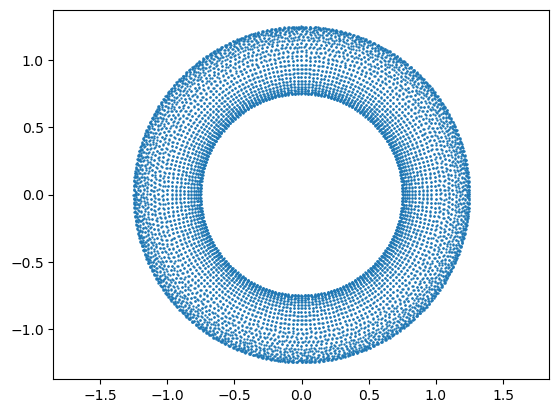

In [11]:
plt.scatter(*v_torus[:,:2].T, s=0.5)
plt.axis('equal')

## Analytical reference values

For a smooth **parametric** surface $\mathbf r(u,v)$ with first fundamental form $E,F,G$ and second
fundamental form $L,M,N$, the Gaussian and mean curvatures are (Wikipedia, *Differential geometry of surfaces*)

$$K = \frac{LN - M^2}{EG - F^2}, \qquad H = \frac{EN - 2FM + GL}{2(EG - F^2)}.$$

Specialised to the test surfaces:

| surface | $K$ | $H$ |
|---|---|---|
| sphere, radius $R$ | $1/R^2$ | $1/R$ |
| torus, radii $a>c$, tube angle $\theta$ | $\dfrac{\cos\theta}{c\,(a+c\cos\theta)}$ | $\dfrac{a+2c\cos\theta}{2c\,(a+c\cos\theta)}$ |
| ellipsoid, $\;q=\tfrac{x^2}{a^4}+\tfrac{y^2}{b^4}+\tfrac{z^2}{c^4}$ | $\dfrac{1}{a^2b^2c^2\,q^2}$ | $\dfrac{\lvert x^2+y^2+z^2-a^2-b^2-c^2\rvert}{2\,a^2b^2c^2\,q^{3/2}}$ |
| Monge patch $z=f(x,y)$, $\;W^2=1+f_x^2+f_y^2$ | $\dfrac{f_{xx}f_{yy}-f_{xy}^2}{W^4}$ | $\dfrac{(1+f_x^2)f_{yy}-2f_xf_yf_{xy}+(1+f_y^2)f_{xx}}{2W^3}$ |

To avoid algebra mistakes and treat every surface uniformly, we evaluate $K$ and $H$ from the
**implicit** representation $F(\mathbf x)=0$ via automatic differentiation (Goldman, *Curvature
formulas for implicit curves and surfaces*, 2005):

$$K = \frac{\nabla F^{\top}\,\operatorname{adj}(\mathbf H_F)\,\nabla F}{\lvert\nabla F\rvert^4},
\qquad
H = \frac{\lvert\nabla F\rvert^2\,\operatorname{tr}(\mathbf H_F) - \nabla F^{\top}\mathbf H_F\,\nabla F}
{2\,\lvert\nabla F\rvert^3},$$

with $\mathbf H_F$ the Hessian of $F$. The sign is fixed so an outward-oriented sphere has
$H=+1/R$ (the library convention: a unit sphere with outward normals has $H=+1$). The cell below
**validates** this autodiff implementation against the closed forms in the table (agreement to
machine precision).

In [18]:
def implicit_curvatures(F, x: Float[jax.Array, "3"]):
    """Gaussian K, mean H, and unit normal at a point x on the implicit surface F(x) = 0.

    Curvatures come from the implicit-surface formulas (Goldman 2005) with the gradient and
    Hessian supplied by autodiff. The normal points along +grad F; the sign of H is chosen so
    an outward-oriented sphere gives H = +1/R.
    """
    g = jax.grad(F)(x)
    Hess = jax.hessian(F)(x)
    gn2 = g @ g
    adj = jnp.array([  # adjugate (transposed cofactor matrix) of the 3x3 Hessian
        [Hess[1,1]*Hess[2,2]-Hess[1,2]*Hess[2,1], Hess[0,2]*Hess[2,1]-Hess[0,1]*Hess[2,2], Hess[0,1]*Hess[1,2]-Hess[0,2]*Hess[1,1]],
        [Hess[1,2]*Hess[2,0]-Hess[1,0]*Hess[2,2], Hess[0,0]*Hess[2,2]-Hess[0,2]*Hess[2,0], Hess[0,2]*Hess[1,0]-Hess[0,0]*Hess[1,2]],
        [Hess[1,0]*Hess[2,1]-Hess[1,1]*Hess[2,0], Hess[0,1]*Hess[2,0]-Hess[0,0]*Hess[2,1], Hess[0,0]*Hess[1,1]-Hess[0,1]*Hess[1,0]]])
    K = (g @ adj @ g) / gn2**2
    H = (gn2*jnp.trace(Hess) - g @ Hess @ g) / (2 * gn2**1.5)
    return K, H, g / jnp.sqrt(gn2)

# implicit level-set F(x) = 0 for each surface (well-defined off-surface too, e.g. at face centroids)
IMPLICIT = {
    "sphere":    lambda x: x @ x - 1.0,
    "ellipsoid": lambda x: (x[0]/1.0)**2 + (x[1]/0.8)**2 + (x[2]/0.6)**2 - 1.0,
    "torus":     lambda x: (jnp.sqrt(x[0]**2 + x[1]**2) - 1.0)**2 + x[2]**2 - 0.25**2,
    "saddle":    lambda x: x[2] - 0.5*(x[0]**2 - x[1]**2),
    "plane":     lambda x: x[2],
}

def analytic_curvature(name, points: Float[jax.Array, "n 3"]):
    """Exact (K, H, unit normal) at each point, from the implicit representation."""
    return jax.vmap(lambda x: implicit_curvatures(IMPLICIT[name], x))(points)

In [19]:
# --- Closed forms (Wikipedia: differential geometry of surfaces / ellipsoid / torus) ---
def sphere_KH(R=1.0):
    return 1/R**2, 1/R

def ellipsoid_KH(x, a=1.0, b=0.8, c=0.6):
    q = (x[...,0]/a**2)**2 + (x[...,1]/b**2)**2 + (x[...,2]/c**2)**2
    K = 1.0 / ((a*b*c)**2 * q**2)
    H = jnp.abs(x[...,0]**2 + x[...,1]**2 + x[...,2]**2 - a**2 - b**2 - c**2) / (2*(a*b*c)**2 * q**1.5)
    return K, H

def torus_KH(x, a=1.0, c=0.25):                 # a: major radius, c: minor radius
    cos_theta = (jnp.sqrt(x[...,0]**2 + x[...,1]**2) - a) / c
    K = cos_theta / (c*(a + c*cos_theta))
    H = (a + 2*c*cos_theta) / (2*c*(a + c*cos_theta))
    return K, H

# Double-check the autodiff formulas against the closed forms on random surface points.
key = jax.random.PRNGKey(0)
p = jax.random.normal(key, (500, 3)); p_sphere = p / jnp.linalg.norm(p, axis=1, keepdims=True)
p_ellip = p_sphere * jnp.array([1.0, 0.8, 0.6])
th = jax.random.uniform(jax.random.PRNGKey(1), (500,), maxval=2*jnp.pi)
ph = jax.random.uniform(jax.random.PRNGKey(2), (500,), maxval=2*jnp.pi)
p_torus = jnp.stack([(1+0.25*jnp.cos(th))*jnp.cos(ph), (1+0.25*jnp.cos(th))*jnp.sin(ph), 0.25*jnp.sin(th)], axis=1)

for name, pts, (Kc, Hc) in [("sphere", p_sphere, sphere_KH()),
                            ("ellipsoid", p_ellip, ellipsoid_KH(p_ellip)),
                            ("torus", p_torus, torus_KH(p_torus))]:
    K, H, _ = analytic_curvature(name, pts)
    print(f"{name:10s}  max|K_autodiff - K_closed| = {float(jnp.max(jnp.abs(K-Kc))):.1e}"
          f"   max|H_autodiff - H_closed| = {float(jnp.max(jnp.abs(H-Hc))):.1e}")

sphere      max|K_autodiff - K_closed| = 4.4e-16   max|H_autodiff - H_closed| = 4.4e-16
ellipsoid   max|K_autodiff - K_closed| = 2.7e-15   max|H_autodiff - H_closed| = 1.8e-15
torus       max|K_autodiff - K_closed| = 8.9e-15   max|H_autodiff - H_closed| = 3.1e-15


In [20]:
# --- small helpers used by the convergence tests below ---
def mean_edge_length(vertices, hemesh):
    """Refinement parameter h: the mean primal edge length."""
    return float(geom.get_he_length(vertices, hemesh).mean())

def align_sign(H_analytic, n_analytic, vertices, hemesh):
    """Flip the analytic mean curvature to match the mesh's (discrete) normal orientation."""
    s = jnp.sign(jnp.sum(geom.get_vertex_normals(vertices, hemesh) * n_analytic))
    return H_analytic * s

def relative_error(discrete, exact, mask=None):
    """Per-entry relative error |discrete - exact| / |exact|, optionally masked to interior vertices."""
    if mask is not None:
        discrete, exact = discrete[mask], exact[mask]
    return jnp.abs(discrete - exact) / jnp.clip(jnp.abs(exact), 1e-12)

### Mean and Gaussian curvature convergence tests

  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Torus_iso_remesh_0.5
  o Torus_iso_remesh_1
  o Torus_iso_remesh_2
  o Torus_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4


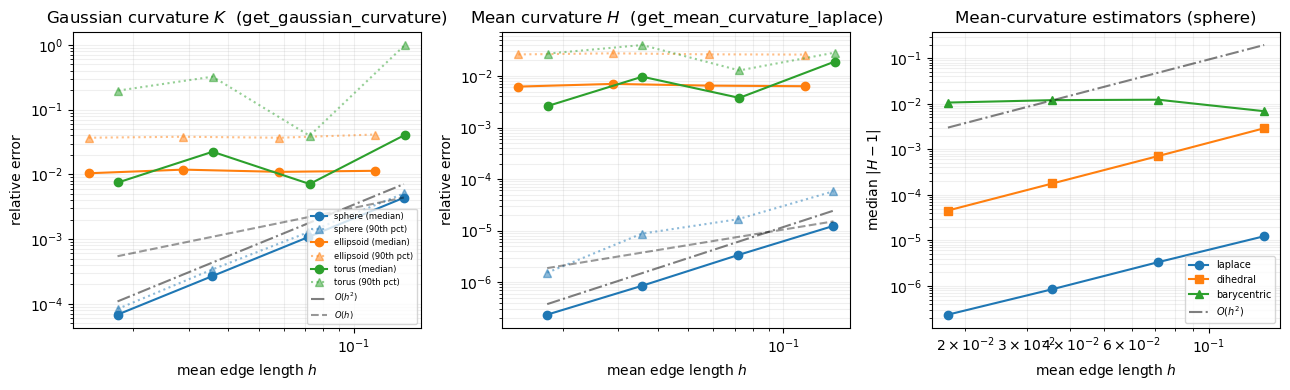

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
sphere_ref = {}
for name in ["sphere", "ellipsoid", "torus"]:
    hs, Kmed, Kp90, Hmed, Hp90 = [], [], [], [], []
    for res in AVAILABLE_RESOLUTIONS:
        v, hm = LOADERS[name](res)
        Kx, Hx, nx = analytic_curvature(name, v)
        Hx = align_sign(Hx, nx, v, hm)
        mask = jnp.ones(v.shape[0], bool) if name in CLOSED_SURFACES else ~hm.is_bdry
        rK = relative_error(geom.get_gaussian_curvature(v, hm), Kx, mask)
        rH = relative_error(geom.get_mean_curvature_laplace(v, hm), Hx, mask)
        hs.append(mean_edge_length(v, hm))
        Kmed.append(float(jnp.median(rK))); Kp90.append(float(jnp.percentile(rK, 90)))
        Hmed.append(float(jnp.median(rH))); Hp90.append(float(jnp.percentile(rH, 90)))
    ax[0].loglog(hs, Kmed, 'o-', color=COLORS[name], label=f"{name} (median)")
    ax[0].loglog(hs, Kp90, '^:', color=COLORS[name], alpha=.5, label=f"{name} (90th pct)")
    ax[1].loglog(hs, Hmed, 'o-', color=COLORS[name]); ax[1].loglog(hs, Hp90, '^:', color=COLORS[name], alpha=.5)
    if name == "sphere": sphere_ref = dict(h=hs, K=Kmed, H=Hmed)

# reference O(h) and O(h^2) slopes, anchored to the sphere curve
hr = jnp.array([min(sphere_ref["h"]), max(sphere_ref["h"])])
for a_, base in zip(ax[:2], [sphere_ref["K"][0], sphere_ref["H"][0]]):
    a_.loglog(hr, base*1.6*(hr/hr[0])**2, 'k-.', alpha=.5, label="$O(h^2)$")
    a_.loglog(hr, base*8.0*(hr/hr[0]),    'k--', alpha=.4, label="$O(h)$")
ax[0].set_title("Gaussian curvature $K$  (get_gaussian_curvature)")
ax[1].set_title("Mean curvature $H$  (get_mean_curvature_laplace)")
ax[0].legend(fontsize=6, loc="lower right")

# panel 3: three mean-curvature estimators on the (near-regular) sphere mesh
methods = {"laplace": geom.get_mean_curvature_laplace,
           "dihedral": geom.get_mean_curvature_dihedral,
           "barycentric": get_mean_curvature_barycentric}
for (label, fn), mk in zip(methods.items(), ['o-', 's-', '^-']):
    hs, em = [], []
    for res in AVAILABLE_RESOLUTIONS:
        v, hm = load_sphere(res)
        hs.append(mean_edge_length(v, hm)); em.append(float(jnp.median(jnp.abs(fn(v, hm) - 1.0))))
    ax[2].loglog(hs, em, mk, label=label)
ax[2].loglog(hr, 3e-3*(hr/hr[0])**2, 'k-.', alpha=.5, label="$O(h^2)$")
ax[2].set_title("Mean-curvature estimators (sphere)"); ax[2].legend(fontsize=7)
ax[2].set_ylabel("median $|H-1|$")
for a_ in ax: a_.set_xlabel("mean edge length $h$"); a_.grid(True, which="both", alpha=.2)
ax[0].set_ylabel("relative error"); ax[1].set_ylabel("relative error")
fig.tight_layout(); plt.show()

In [20]:
# Cross-check against igl: our angle-defect Gaussian curvature matches igl's to machine precision,
# so any non-convergence below is a property of the discretisation, not an implementation bug.
v, hm = load_sphere(1); vn, fn = np.asarray(v), np.asarray(hm.faces).astype(np.int64)
K_igl = igl.gaussian_curvature(vn, fn) / np.asarray(igl.massmatrix(vn, fn, igl.MASSMATRIX_TYPE_VORONOI).diagonal())
print("sphere  max|get_gaussian_curvature - igl| =",
      float(jnp.max(jnp.abs(geom.get_gaussian_curvature(v, hm) - K_igl))))

sphere  max|get_gaussian_curvature - igl| = 2.6916247009012295e-12


  o Sphere_iso_remesh_1


**Findings — curvature.** On the near-regular **sphere** remesh, both $K$ and $H$ converge at the
expected **second order** in the bulk (median $\sim h^2$, tracking the $O(h^2)$ guide). The
*worst-case* error (90th percentile, dotted) however **stagnates**: a few irregular vertices carry
$O(1)$ error that does not vanish. On the **ellipsoid** — the *same* mesh, merely scaled by
$(1,0.8,0.6)$ — even the median stagnates, because the anisotropic scaling destroys the local
(near-hexagonal) symmetry of the vertex stars. The **torus** is intermediate and noisy. This is the
well-known requirement that angle-defect / cotan curvature estimators need mesh regularity for
*pointwise* convergence (integrated quantities such as $\int K\,dA = 2\pi\chi$ stay exact). The
estimators match `igl` to machine precision, so this is a discretisation property, **not** a bug.
Among the mean-curvature estimators (right panel) `get_mean_curvature_laplace` is the most accurate
and the `barycentric` one (dihedral angles / barycentric area) is the worst — as anticipated in the
introduction.

## Convergence theory: what is actually guaranteed?

The stagnation above is expected from the literature: the angle-defect and cotangent estimators are
**not** guaranteed to converge *pointwise* on general meshes. What *is* guaranteed is convergence in
an **integrated / weak ("measure")** sense.

**Gaussian curvature (angle defect).** The Gauss–Bonnet angle defect $2\pi-\sum_i\theta_i$ is the
*integral* of $K$ over the vertex's dual cell up to higher order. Divided by the cell area (i.e.
pointwise) it converges only on special meshes: $O(h^2)$ when the one-ring is *regular / satisfies a
parallelogram condition* (valence 6), $O(h)$ under weaker regularity, and **not at all** at generic
irregular vertices (Xu 2006; Borrelli–Cazals–Morvan 2003; Mohammadi et al. 2021). Meyer et al.'s
guarantee is really the *integrated* statement — summed over a region the angle defect approximates
$\int_P K\,dA$, and over a closed surface it equals $2\pi\chi$ *exactly* (Gauss–Bonnet). The sharp
result is Cohen-Steiner & Morvan's normal-cycle theorem: the discrete curvature **measures** converge
to the smooth ones over any fixed region, **linearly** $O(h)$ in the sampling density, under mild
local-uniformity conditions — with no pointwise claim.

**Mean curvature (cotangent formula).** The cotan Laplacian converges to the Laplace–Beltrami
operator (we saw $O(h)$ above), but the mean-curvature vector $\tfrac12 M^{-1}Lx = Hn$ converges only
in the sense of **distributions** and *fails* in $L^2$/pointwise in general (Hildebrandt–Polthier–
Wardetzky 2006; Wardetzky 2008): a polyhedral surface's mean curvature is genuinely a distribution
concentrated on the edges, so only its pairing with smooth test functions — e.g. its integral over a
fixed region — is meaningful. Under *total normal convergence* (meshes approaching the surface in
Hausdorff distance **and** normals converging uniformly) the mean-curvature functionals converge in
norm.

**Bottom line.** Expect **weak / measure convergence**, not pointwise: test the estimators by
integrating over regions of *fixed* size (independent of $h$), not by reading per-vertex values
(whose dual cells shrink as $h\to0$). The next section does exactly that.

### Laplace and gradient operator convergence tests

  o Plane_iso_remesh_0.5
  o Plane_iso_remesh_1
  o Plane_iso_remesh_2
  o Plane_iso_remesh_4
  o Plane_iso_remesh_0.5
  o Plane_iso_remesh_1
  o Plane_iso_remesh_2
  o Plane_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Torus_iso_remesh_0.5
  o Torus_iso_remesh_1
  o Torus_iso_remesh_2
  o Torus_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Plane_iso_remesh_0.5
  o Plane_iso_remesh_1
  o Plane_iso_remesh_2
  o Plane_iso_remesh_4


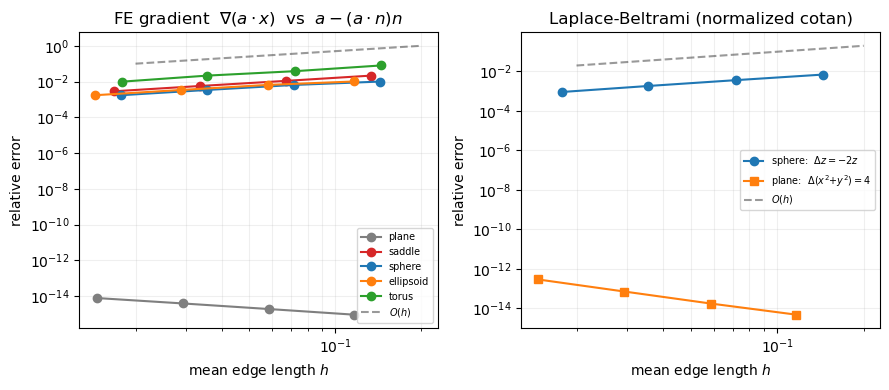

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

# (a) FE gradient of an ambient-linear field u = a . x. Its intrinsic surface gradient is the
#     tangential projection  grad_S u = a - (a . n) n,  evaluated with the *smooth* normal n.
a_vec = jnp.array([1.0, 2.0, -1.0])
for name in LOADERS:
    hs, err = [], []
    for res in AVAILABLE_RESOLUTIONS:
        v, hm = LOADERS[name](res)
        grad = linops.compute_gradient_3d(v, hm, v @ a_vec)                # (n_faces, 3), constant per face
        centroids = v[hm.faces].mean(axis=1)
        _, _, n = analytic_curvature(name, centroids)                      # smooth surface normal at centroid
        grad_exact = a_vec - jnp.sum(a_vec*n, axis=1, keepdims=True)*n
        hs.append(mean_edge_length(v, hm))
        err.append(float(jnp.linalg.norm(grad - grad_exact) / jnp.linalg.norm(grad_exact)))
    ax[0].loglog(hs, jnp.clip(jnp.asarray(err), 1e-16, None), 'o-', color=COLORS[name], label=name)
hr = jnp.array([0.02, 0.2]); ax[0].loglog(hr, 0.1*(hr/hr[0]), 'k--', alpha=.4, label="$O(h)$")
ax[0].set_title("FE gradient  $\\nabla(a\\cdot x)$  vs  $a-(a\\cdot n)n$"); ax[0].legend(fontsize=7)

# (b) area-normalized cotan Laplacian = Laplace-Beltrami.
#     sphere: Delta_S z = -2 z (unit-sphere eigenfunction, l=1);   plane: Delta(x^2+y^2) = 4.
for label, loader, field, exact, mk in [
        ("sphere:  $\\Delta z = -2z$", load_sphere, lambda v: v[:,2], lambda v: -2*v[:,2], 'o-'),
        ("plane:  $\\Delta(x^2{+}y^2)=4$", load_plane, lambda v: v[:,0]**2+v[:,1]**2,
         lambda v: jnp.full(v.shape[0], 4.0), 's-')]:
    hs, err = [], []
    for res in AVAILABLE_RESOLUTIONS:
        v, hm = loader(res)
        lap = linops.compute_cotan_laplace(v, hm, field(v), normalize=True)
        ex = exact(v); mask = jnp.ones(v.shape[0], bool) if loader is load_sphere else ~hm.is_bdry
        hs.append(mean_edge_length(v, hm))
        err.append(float(jnp.linalg.norm((lap-ex)[mask]) / jnp.linalg.norm(ex[mask])))
    ax[1].loglog(hs, jnp.clip(jnp.asarray(err), 1e-16, None), mk, label=label)
ax[1].loglog(hr, 0.02*(hr/hr[0]), 'k--', alpha=.4, label="$O(h)$")
ax[1].set_title("Laplace-Beltrami (normalized cotan)"); ax[1].legend(fontsize=7)
for a_ in ax: a_.set_xlabel("mean edge length $h$"); a_.set_ylabel("relative error"); a_.grid(True, which="both", alpha=.2)
fig.tight_layout(); plt.show()

**Findings — operators.** The FE **gradient** converges at first order, $O(h)$, on all curved
surfaces and is machine-exact on the flat plane (the P1 gradient of an ambient-linear field is
reproduced exactly on each triangle, so the only error is the deviation of the triangle plane from
the tangent plane). The area-normalized cotangent **Laplacian** (Laplace-Beltrami) converges $O(h)$
on the sphere — tested on the eigenfunction $z$ with $\Delta_S z = -2z$ — and is machine-exact on the
plane ($\Delta(x^2+y^2)=4$). These operators are the workhorses for PDEs on surfaces and behave as
expected.

### Metric tensor and 2nd fundamental form convergence tests

  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Torus_iso_remesh_0.5
  o Torus_iso_remesh_1
  o Torus_iso_remesh_2
  o Torus_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4
  o Torus_iso_remesh_0.5
  o Torus_iso_remesh_1
  o Torus_iso_remesh_2
  o Torus_iso_remesh_4


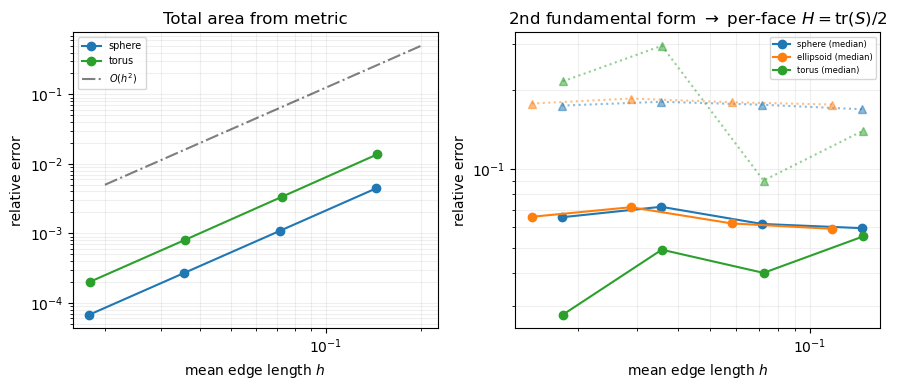

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))

# (a) total surface area from the metric (first fundamental form) vs the exact area
true_area = {"sphere": 4*np.pi, "torus": 4*np.pi**2 * 1.0 * 0.25}
for name in ["sphere", "torus"]:
    hs, err = [], []
    for res in AVAILABLE_RESOLUTIONS:
        v, hm = LOADERS[name](res)
        area = float(elastic.get_area_from_metric(elastic.get_metric(v, hm)).sum())
        hs.append(mean_edge_length(v, hm)); err.append(abs(area - true_area[name]) / true_area[name])
    ax[0].loglog(hs, err, 'o-', color=COLORS[name], label=name)
hr = jnp.array([0.02, 0.2]); ax[0].loglog(hr, 5e-3*(hr/hr[0])**2, 'k-.', alpha=.5, label="$O(h^2)$")
ax[0].set_title("Total area from metric"); ax[0].legend(fontsize=7)

# (b) shape operator S = g^-1 b from metric + second fundamental form -> per-face mean curvature tr(S)/2
for name in ["sphere", "ellipsoid", "torus"]:
    hs, med, p90 = [], [], []
    for res in AVAILABLE_RESOLUTIONS:
        v, hm = LOADERS[name](res)
        S = elastic.get_two_x_two_inverse(elastic.get_metric(v, hm)) @ elastic.get_second_fundamental_form(v, hm)
        H_face = 0.5 * jnp.trace(S, axis1=1, axis2=2)
        centroids = v[hm.faces].mean(axis=1)
        _, Hx, nx = analytic_curvature(name, centroids)
        Hx = Hx * jnp.sign(jnp.sum(geom.get_triangle_normals(v, hm) * nx))
        r = jnp.abs(H_face - Hx) / jnp.clip(jnp.abs(Hx), 1e-9)
        hs.append(mean_edge_length(v, hm)); med.append(float(jnp.median(r))); p90.append(float(jnp.percentile(r, 90)))
    ax[1].loglog(hs, med, 'o-', color=COLORS[name], label=f"{name} (median)")
    ax[1].loglog(hs, p90, '^:', color=COLORS[name], alpha=.5)
ax[1].set_title("2nd fundamental form $\\to$ per-face $H=\\mathrm{tr}(S)/2$"); ax[1].legend(fontsize=6)
for a_ in ax: a_.set_xlabel("mean edge length $h$"); a_.set_ylabel("relative error"); a_.grid(True, which="both", alpha=.2)
fig.tight_layout(); plt.show()

**Findings — metric & second fundamental form.** The total area recovered from the metric (first
fundamental form) converges at **second order**, $O(h^2)$ (`get_metric` is the *exact* Gram matrix of
the triangle edges, so this measures how fast the piecewise-linear area approaches the smooth area).
The per-face shape operator $S=g^{-1}b$ assembled from `get_second_fundamental_form` (a mid-edge-normal
finite difference, Grinspun et al. 2006) recovers the mean curvature *in the median* — sphere and
ellipsoid land within a few percent — but carries an $O(1)$ per-face noise floor that does **not**
decay with $h$. It is a low-order, per-face estimator by construction; for accurate per-vertex
curvature the operators in the first section are preferable.

## Region-averaged curvature on the ellipsoid (measure convergence)

We now test $\displaystyle \int_P H\,dA = \frac{\int_P H\,dA}{\int_P dA}$ and $\int_P K\,dA$ over
**fixed** patches that do not shrink under refinement. The ellipsoid is split into $6$ latitude bands
(by the polar angle of the underlying sphere parametrisation); each band has a distinct true average
curvature. The discrete integrals use the *un-normalised* estimators
$\int_P H\,dA \approx \sum_{i\in P}$`get_mean_curvature_laplace(..., normalize=False)` and
$\int_P K\,dA \approx \sum_{i\in P}(2\pi-\sum\theta)_i$, with patch area $\sum_{i\in P}A_i$. The
smooth reference comes from a fine parametric quadrature of the exact $H,K$.

  o Sphere_iso_remesh_0.25
  o Sphere_iso_remesh_0.5
  o Sphere_iso_remesh_1
  o Sphere_iso_remesh_2
  o Sphere_iso_remesh_4


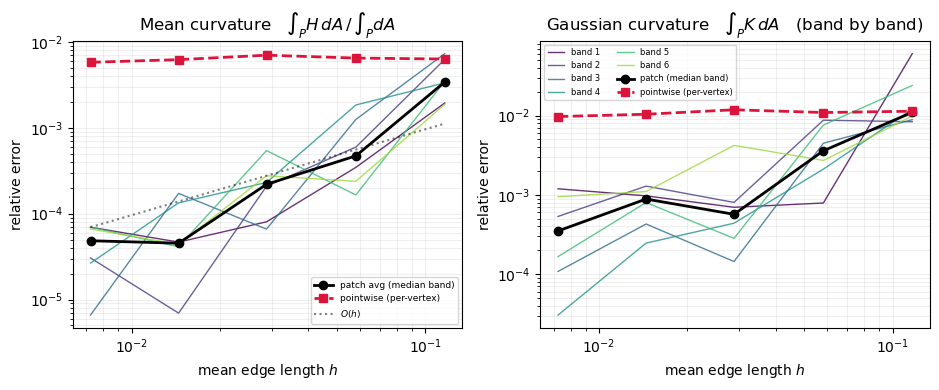

In [27]:
a, b, c = 1.0, 0.8, 0.6
N_BANDS = 6
band_edges = np.linspace(0, np.pi, N_BANDS + 1)   # latitude bands in the sphere-preimage polar angle

# --- smooth reference: fine parametric quadrature of the exact H, K over each band ---
n_theta, n_phi = 1800, 900
theta = (np.arange(n_theta) + 0.5) * np.pi / n_theta
phi   = (np.arange(n_phi) + 0.5) * 2*np.pi / n_phi
TH, PH = np.meshgrid(theta, phi, indexing="ij")
Xg, Yg, Zg = a*np.sin(TH)*np.cos(PH), b*np.sin(TH)*np.sin(PH), c*np.cos(TH)
Kg, Hg, _ = analytic_curvature("ellipsoid", jnp.asarray(np.stack([Xg, Yg, Zg], -1).reshape(-1, 3)))
Kg, Hg = np.asarray(Kg).reshape(TH.shape), np.asarray(Hg).reshape(TH.shape)
r_th = np.stack([a*np.cos(TH)*np.cos(PH), b*np.cos(TH)*np.sin(PH), -c*np.sin(TH)], -1)
r_ph = np.stack([-a*np.sin(TH)*np.sin(PH), b*np.sin(TH)*np.cos(PH), np.zeros_like(TH)], -1)
dA_g = np.linalg.norm(np.cross(r_th, r_ph), axis=-1) * (np.pi/n_theta) * (2*np.pi/n_phi)
band_g = np.clip(np.digitize(TH, band_edges) - 1, 0, N_BANDS - 1)
true_meanH = {o: float((Hg[band_g==o]*dA_g[band_g==o]).sum() / dA_g[band_g==o].sum()) for o in range(N_BANDS)}
true_intK  = {o: float((Kg[band_g==o]*dA_g[band_g==o]).sum()) for o in range(N_BANDS)}

# --- discrete region averages vs mesh refinement (contrasted with the pointwise per-vertex error) ---
fig, ax = plt.subplots(1, 2, figsize=(9.5, 4)); band_colors = plt.cm.viridis(np.linspace(0, .85, N_BANDS))
hs, eH_band, eK_band, pw_H, pw_K = [], {o: [] for o in range(N_BANDS)}, {o: [] for o in range(N_BANDS)}, [], []
for res in AVAILABLE_RESOLUTIONS:
    v, hm = load_ellipsoid(res); vv = np.asarray(v)
    _, _, n_ell = analytic_curvature("ellipsoid", v)
    H_int = np.asarray(align_sign(geom.get_mean_curvature_laplace(v, hm, normalize=False), n_ell, v, hm))
    K_int = 2*np.pi - np.asarray(geom.get_angle_sum(v, hm))          # integrated Gaussian curvature (angle defect)
    A_i   = np.asarray(geom.get_voronoi_areas_robust(v, hm))
    band_id = np.clip(np.digitize(np.arccos(np.clip(vv[:, 2]/c, -1, 1)), band_edges) - 1, 0, N_BANDS - 1)
    hs.append(mean_edge_length(v, hm))
    for o in range(N_BANDS):
        m = band_id == o
        eH_band[o].append(abs(H_int[m].sum()/A_i[m].sum() - true_meanH[o]) / abs(true_meanH[o]))
        eK_band[o].append(abs(K_int[m].sum() - true_intK[o]) / abs(true_intK[o]))
    Kx, Hx, nx = analytic_curvature("ellipsoid", v); Hx = align_sign(Hx, nx, v, hm)
    pw_H.append(float(jnp.median(jnp.abs(geom.get_mean_curvature_laplace(v, hm) - Hx) / jnp.abs(Hx))))
    pw_K.append(float(jnp.median(jnp.abs(geom.get_gaussian_curvature(v, hm) - Kx) / jnp.abs(Kx))))

for o in range(N_BANDS):
    ax[0].loglog(hs, eH_band[o], '-', color=band_colors[o], lw=1, alpha=.8)
    ax[1].loglog(hs, eK_band[o], '-', color=band_colors[o], lw=1, alpha=.8, label=f"band {o+1}")
ax[0].loglog(hs, np.median(list(eH_band.values()), axis=0), 'o-k', lw=2, label="patch avg (median band)")
ax[0].loglog(hs, pw_H, 's--', color="crimson", lw=2, label="pointwise (per-vertex)")
ax[1].loglog(hs, np.median(list(eK_band.values()), axis=0), 'o-k', lw=2, label="patch (median band)")
ax[1].loglog(hs, pw_K, 's--', color="crimson", lw=2, label="pointwise (per-vertex)")
hr = np.array([min(hs), max(hs)]); ax[0].loglog(hr, eH_band[0][0]/hs[0]*hr, 'k:', alpha=.5, label="$O(h)$")
ax[0].set_title(r"Mean curvature   $\int_P H\,dA\,/\,\int_P dA$")
ax[1].set_title(r"Gaussian curvature   $\int_P K\,dA$   (band by band)")
ax[0].legend(fontsize=6.5); ax[1].legend(fontsize=6, ncol=2)
for a_ in ax: a_.set_xlabel("mean edge length $h$"); a_.set_ylabel("relative error"); a_.grid(True, which="both", alpha=.2)
fig.tight_layout(); plt.show()

Actually, some meshes are not Delaunay! Let's fix this.

In [25]:
v, hm = load_torus(2)

  o Torus_iso_remesh_2


In [26]:
weights = geom.get_cotan_weights_per_edge(v, hm)
weights.min(), 100*jnp.mean(weights < 0)

(Array(-0.06687929, dtype=float64), Array(11.164136, dtype=float32))

In [27]:
hm_new, n_flips = alg.fix_delaunay(v, hm, max_iters=2)
n_flips, 2*n_flips/hm.n_hes

# 40s for 2 iterations on 0.5. 

/Users/nc1333/miniforge3/envs/triangulax/lib/python3.14/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


(Array(772, dtype=int64), Array(0.11164136, dtype=float64))

In [38]:
igl.is_edge_manifold(np.array(hm_new.faces))[0], igl.is_vertex_manifold(np.array(hm_new.faces))[0]

(True, np.True_)

In [28]:
weights_new = geom.get_cotan_weights_per_edge(v, hm_new)
weights_new.min(), 100*jnp.mean(weights_new < 0)

(Array(0.00079589, dtype=float64), Array(0., dtype=float32))

**Findings — region averages.** Over **fixed** patches the estimators clearly converge (black
curves), at roughly the $O(h)$ rate predicted by measure-convergence theory, while the **pointwise**
per-vertex error (red) stays flat. The two notions of convergence genuinely differ. Practical
takeaway: on irregular meshes the discrete curvatures are meaningful as *densities to be integrated*
over regions, not as per-vertex pointwise values. (For the whole surface $\int_P K\,dA = 4\pi$ holds
to machine precision by Gauss–Bonnet, and — as you noted — the global $\int H\,dA$ is a single number
the estimator already reproduces; the per-band test is the spatially-resolved, more stringent
version.)

## Summary

| quantity | operator | behaviour under refinement |
|---|---|---|
| Gaussian curvature $K$ | `geom.get_gaussian_curvature` | $O(h^2)$ in the bulk on regular meshes; stagnates otherwise |
| Mean curvature $H$ | `geom.get_mean_curvature_laplace` | $O(h^2)$ in the bulk; accuracy `laplace` > `dihedral` > `barycentric` |
| Gradient | `linops.compute_gradient_3d` | $O(h)$; exact on flat meshes |
| Laplace-Beltrami | `linops.compute_cotan_laplace` (normalized) | $O(h)$; exact on flat meshes |
| Metric / area | `elastic.get_metric` | total area $O(h^2)$ |
| 2nd fundamental form | `elastic.get_second_fundamental_form` | consistent (median) but $O(1)$ per-face noise |

**No bugs were found:** the curvature operators reproduce `igl` to machine precision. The pointwise
non-convergence of the angle-defect / cotan curvatures and of the mid-edge-normal second fundamental
form is a documented property of those discretisations (they require mesh-regularity conditions for
pointwise convergence), not an implementation error.

*Caveat on the error metric:* curvature **relative** error is ill-conditioned wherever the curvature
crosses zero — torus $K$ near the top/bottom circles ($\theta=\pm\pi/2$) and saddle $H$ on the lines
$|x|=|y|$. There we report an absolute or sign-definite quantity instead (e.g. the saddle is a clean
test for $K<0$, and the flat plane gives $K=H=0$ to machine precision).

**On convergence type.** The pointwise non-convergence is not a defect to fix: the angle-defect and cotangent estimators converge in the **measure / weak** sense (Cohen-Steiner–Morvan 2003; Hildebrandt–Polthier–Wardetzky 2006), i.e. *integrated over fixed regions* — verified on the ellipsoid above — not pointwise, which requires mesh regularity (valence-6 / parallelogram).